## Customer Churn Analysis Using Python

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("C:/Users/Apurva Malankar/Downloads/telco_churn.csv")
df

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000381469727,False
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.5,False
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.1500015258789,True
3,3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.64999389648438,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,2038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.800000,1990.5,No
5039,2039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.200000,7362.9,No
5040,2040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.600000,346.45,No
5041,2041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.400000,306.6,Yes


In [6]:
print(df.shape)

(5043, 22)


In [7]:
print(df.head())

   Unnamed: 0  customerID  gender SeniorCitizen Partner Dependents  tenure  \
0           0  7590-VHVEG  Female         False    True      False       1   
1           1  5575-GNVDE    Male         False   False      False      34   
2           2  3668-QPYBK    Male         False   False      False       2   
3           3  7795-CFOCW    Male         False   False      False      45   
4           4  9237-HQITU  Female         False   False      False       2   

  PhoneService MultipleLines InternetService  ... DeviceProtection  \
0        False           NaN             DSL  ...            False   
1         True         False             DSL  ...             True   
2         True         False             DSL  ...            False   
3        False           NaN             DSL  ...             True   
4         True         False     Fiber optic  ...            False   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0       False       False       

In [8]:
print(df.columns)

Index(['Unnamed: 0', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='str')


In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.isnull().sum()

Unnamed: 0            0
customerID            0
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       269
InternetService       0
OnlineSecurity      651
OnlineBackup        651
DeviceProtection    651
TechSupport         651
StreamingTV         651
StreamingMovies     651
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges          8
Churn                 1
dtype: int64

In [10]:
df=df.dropna()

In [11]:
print(df.head())

   Unnamed: 0  customerID  gender SeniorCitizen Partner Dependents  tenure  \
1           1  5575-GNVDE    Male         False   False      False      34   
2           2  3668-QPYBK    Male         False   False      False       2   
4           4  9237-HQITU  Female         False   False      False       2   
5           5  9305-CDSKC  Female         False   False      False       8   
6           6  1452-KIOVK    Male         False   False       True      22   

  PhoneService MultipleLines InternetService  ... DeviceProtection  \
1         True         False             DSL  ...             True   
2         True         False             DSL  ...            False   
4         True         False     Fiber optic  ...            False   
5         True          True     Fiber optic  ...             True   
6         True          True     Fiber optic  ...            False   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
1       False       False       

In [12]:
df['Churn'].unique()

<StringArray>
['False', 'True', 'No', 'Yes']
Length: 4, dtype: str

In [13]:
df['Churn'] = df['Churn'].apply(
    lambda x: 1 if str(x).strip().lower() in ['yes','true'] else 0
)

In [24]:
df

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.500000,0
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.150002,1
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.649994,1
5,5,9305-CDSKC,Female,False,False,False,8,True,True,Fiber optic,...,True,False,True,True,Month-to-month,True,Electronic check,99.650002,820.500000,1
6,6,1452-KIOVK,Male,False,False,True,22,True,True,Fiber optic,...,False,False,True,False,Month-to-month,True,Credit card (automatic),89.099998,1949.400024,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,2038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.800000,1990.500000,0
5039,2039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.200000,7362.900000,0
5040,2040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.600000,346.450000,0
5041,2041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.400000,306.600000,1


In [14]:
df['Churn'].value_counts()

Churn
0    2886
1    1232
Name: count, dtype: int64

In [15]:
#visualization of churn

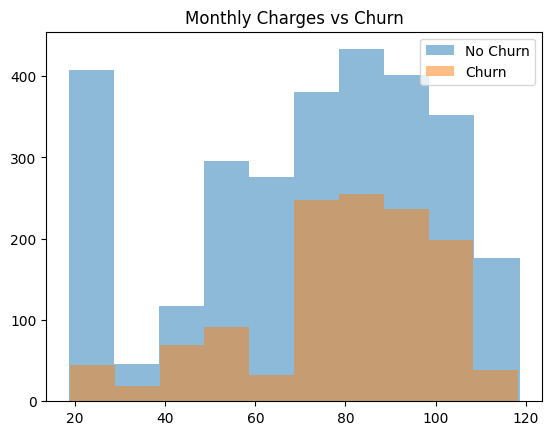

In [16]:
plt.hist(df[df['Churn']==0]['MonthlyCharges'], alpha=0.5, label='No Churn')
plt.hist(df[df['Churn']==1]['MonthlyCharges'], alpha=0.5, label='Churn')
plt.legend()
plt.title("Monthly Charges vs Churn")
plt.show()

Histogram analysis shows that customers with higher monthly charges exhibit a higher tendency to churn.<br> However, significant overlap between churned and retained customers suggests that churn depends on multiple factors such as tenure, contract type, and service features.

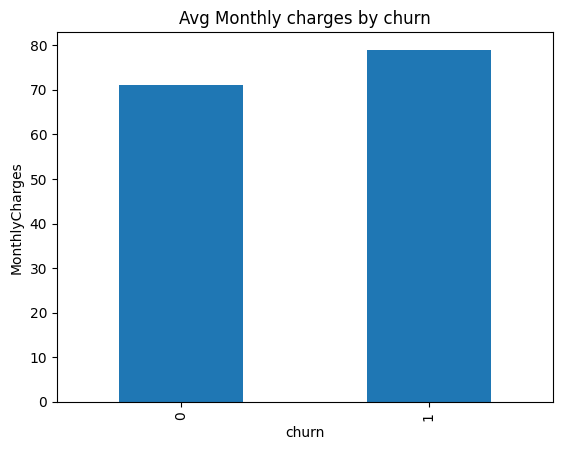

In [17]:
df.groupby('Churn')['MonthlyCharges'].mean().plot(kind='bar')
plt.xlabel('churn')
plt.ylabel('MonthlyCharges')
plt.title("Avg Monthly charges by churn")
plt.show()

Customers with higher monthly charges show a greater tendency to churn,<br>
indicating pricing sensitivity and potential dissatisfaction with service cost.

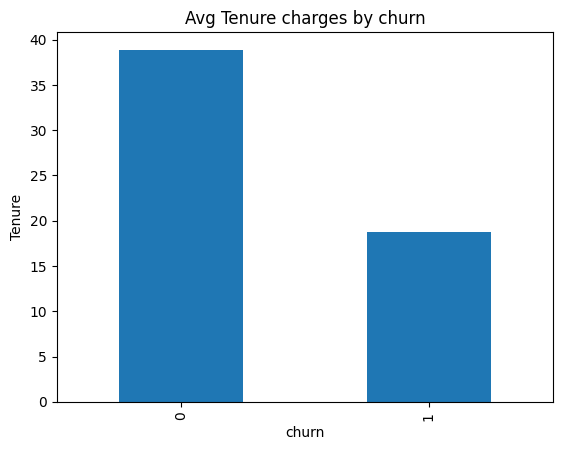

In [18]:
df.groupby('Churn')['tenure'].mean().plot(kind='bar')
plt.xlabel('churn')
plt.ylabel('Tenure')
plt.title("Avg Tenure charges by churn")
plt.show()

Customers with shorter tenure are significantly more likely to churn, whereas on the other hand customers with high tenure have very less chances of churning; <br>  Suggesting that early customer engagement and retention strategies are crucial.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df[['tenure', 'MonthlyCharges']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

prediction=model.predict(X_test)
print("Prediction:",prediction)

print("Accuracy of model:",accuracy_score(y_test,prediction))

Prediction: [0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1
 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0
 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1
 1 0 0 0 1 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 1
 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0
 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1
 1 0 0 0 0 0 

A Logistic Regression Model was trained using values of "Tenure" and "MonthlyCharges" as the inputs and "churn" as the target variable<br>
this indicates that the customer with high Monthlycharges and low tenure are most likely to churn<br> 
This confirms insights obtained during exploratory data analysis and highlights the importance of pricing and customer engagement strategies.

In [20]:
#evaluation of the project

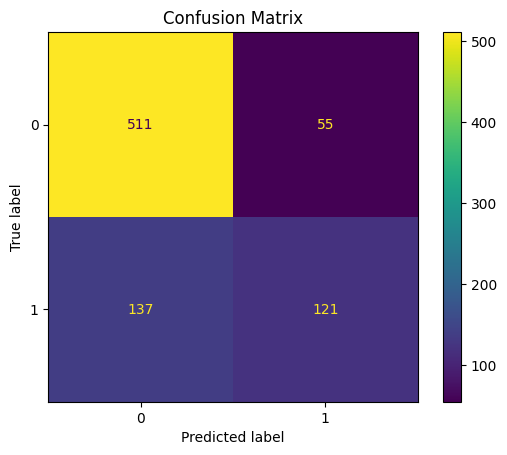

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on test data
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

The model performs well for non-churn prediction but has low recall for churn, missing a significant number of actual churners

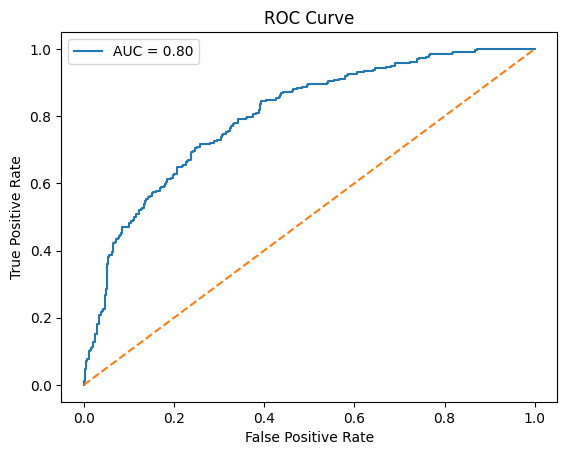

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

# Computing ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Computing AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC-AUC score of 0.80 indicates good model capability in distinguishing churn and non-churn customers

The model achieved ~77% accuracy. However, the confusion matrix shows a high number of false negatives, meaning many churn customers are missed.<br> The ROC-AUC score of 0.80 indicates that the model has good potential, but threshold tuning is needed to improve recall